# Intial Route Optimization Agentic Workflow

<img src="img.png" width="100%">

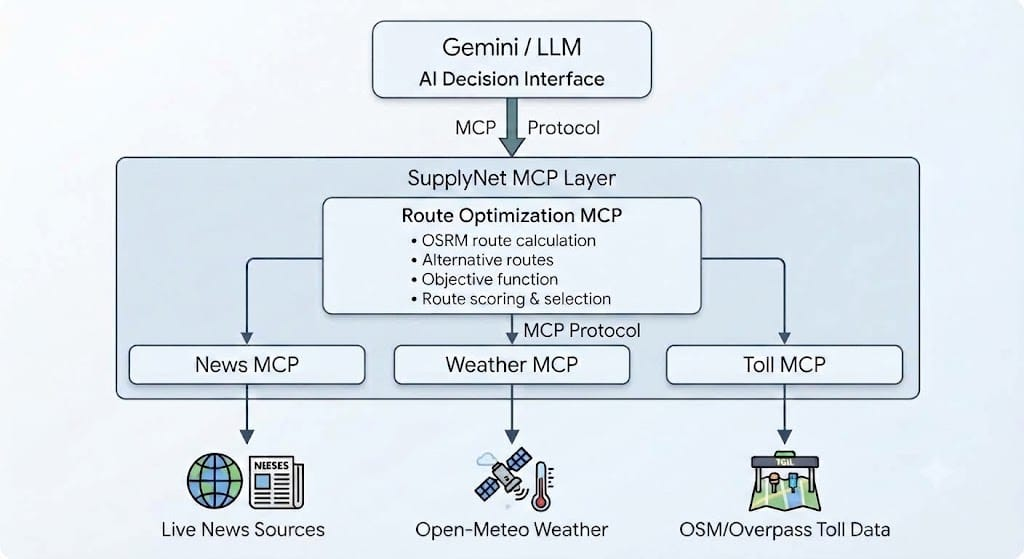

### Hiarchical struture

<img src="img2.png" width="60%">

#### Understanding Agents connection

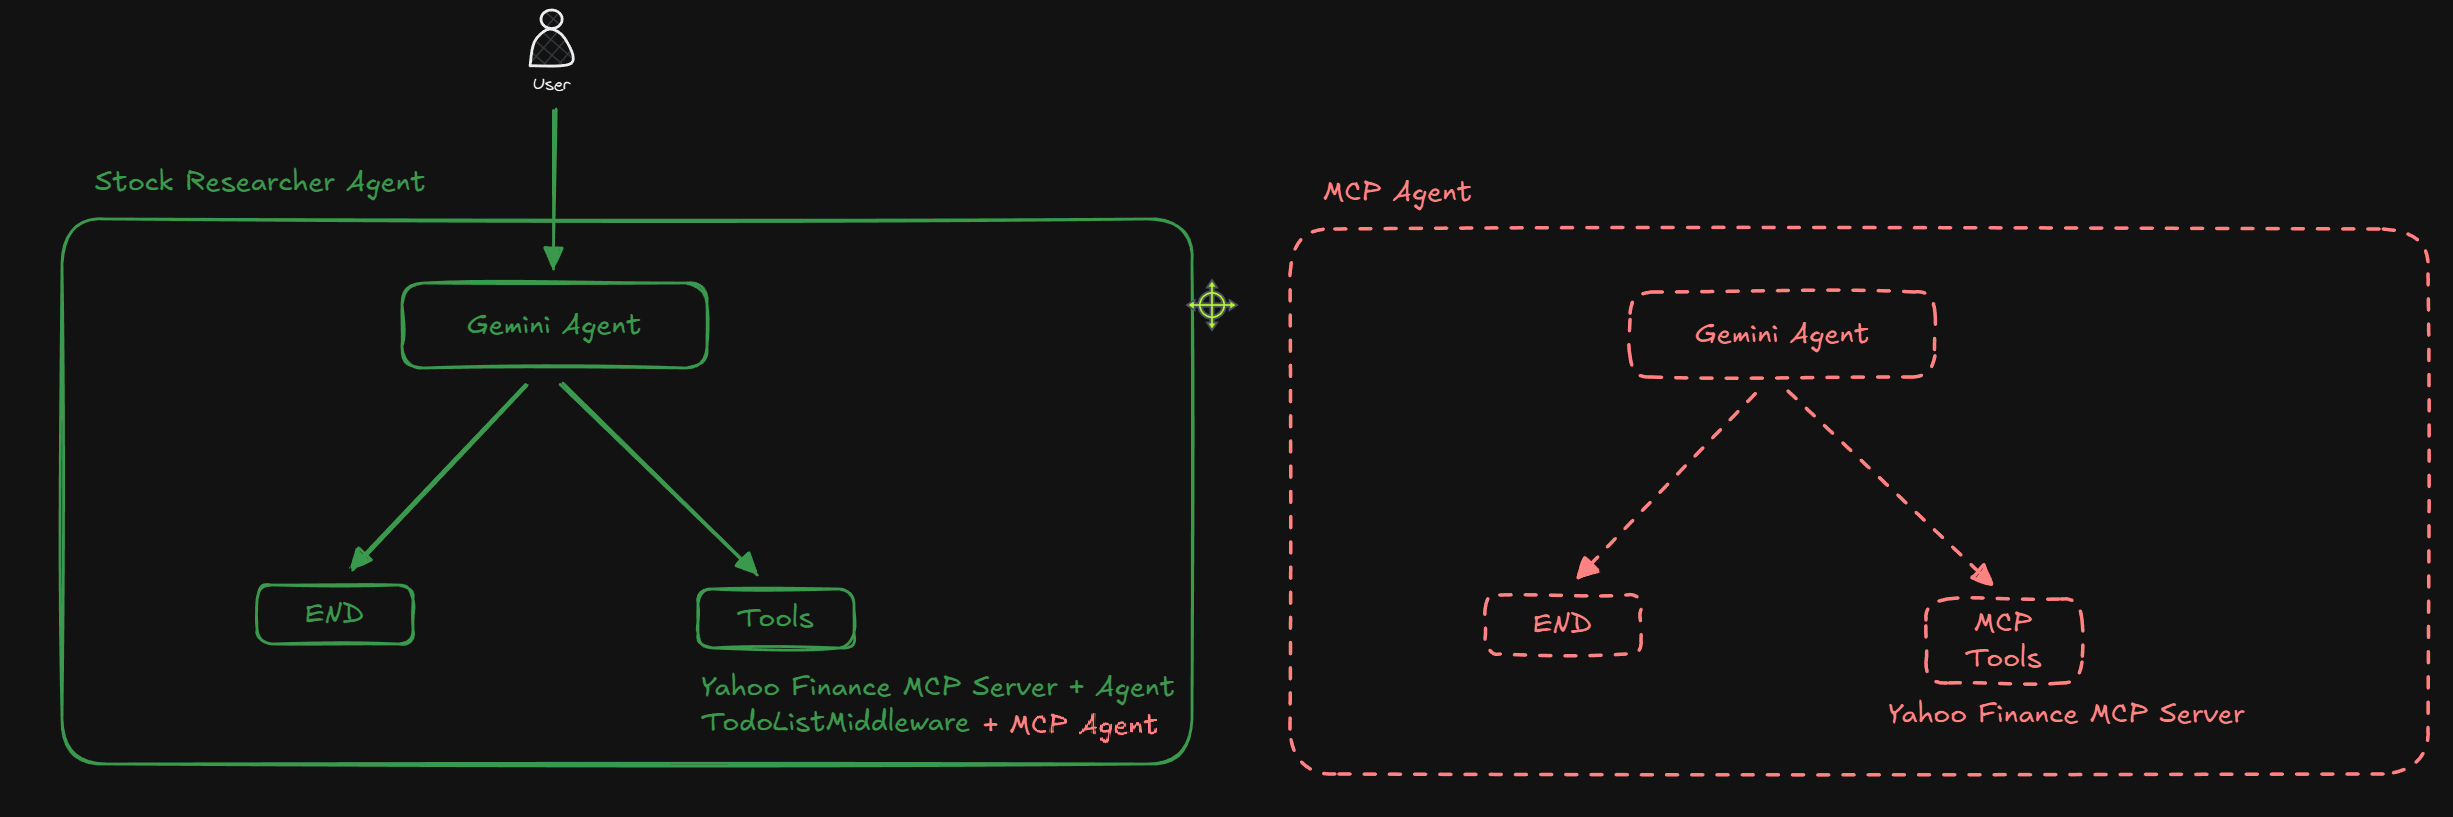

### Multi Agent flow

<img src="img1.png" width="70%">

---

### *Pre-preparation

In [1]:
import warnings 
warnings.filterwarnings("ignore")

In [2]:
from dotenv import load_dotenv
load_dotenv()

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.agents import create_agent
from langchain_core.messages import HumanMessage

from langchain_core.tools import tool
from langchain.agents.middleware import TodoListMiddleware
from SupplyNet_MCP.scripts.agent_utils import stream_agent_response


import subprocess
import sys
import os
from pathlib import Path


In [3]:
# Fetch the variable
api_key = os.getenv("GOOGLE_API_KEY")

# Test output
if api_key:
    # Print masked value to verify it loaded without exposing the secret
    print(f"Loaded successfully! Key starts with: {api_key[:8]}...")
else:
    print("Failed to load: GEMINI_API_KEY is None or not found.")

Loaded successfully! Key starts with: AQ.Ab8RN...


In [ ]:
model = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')

In [ ]:
model = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')

# <span style="color: yellow;">Creating Sub-Agents</span>

## <span style="color: #3182ce;">Route Researcher Agent</span>
- `route_researcher`: Fetches real-world ground data via MCP servers, including OSRM distances, waypoints/geometry, current weather risks, traffic disruptions, and toll charges.



In [5]:
import importlib
import subprocess
import sys
from langchain_core.tools import tool


@tool
def route_researcher(query: str) -> str:
    """Research route logistics, weather hazards, traffic disruptions, and toll costs.

    Call this tool whenever you need to analyze transport routes, highway
    hazards, or toll charges.
    """
    python_exe = sys.executable

    clean_query = query.replace("'", "\\'")

    code = f"""
import sys
import asyncio
import importlib

# Force UTF-8 stdout encoding for Windows console streams
if sys.platform == "win32":
    sys.stdout.reconfigure(encoding="utf-8")

supply_mcp = importlib.import_module("SupplyNet_MCP.scripts.supplyNet_mcp")
route_research = supply_mcp.route_research

asyncio.run(route_research('''{clean_query}'''))
"""

    result = subprocess.run(
        [python_exe, "-c", code],
        capture_output=True,
        text=True,
        encoding="utf-8",  # Enforces UTF-8 decoding for subprocess output
        errors="replace",  # Prevents crashes if any non-standard bytes appear
    )

    if result.returncode != 0:
        return f"Error executing supply chain research:\n{result.stderr}"

    return result.stdout.strip()

#### Route Researcher Agent Testing

In [6]:
query = "What is the best route from Delhi to vellore."
response = route_researcher.invoke({'query': query})

In [ ]:
#stream_agent_response(route_researcher, query)

ValidationError: 1 validation error for route_researcher
query
  Field required [type=missing, input_value={'messages': [HumanMessag...fault', 'user_id': None}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

In [7]:
print(response)

Loaded 18 tools
Tools available: ['get_traffic_news', 'get_traffic_news_summary', 'report_disruption', 'check_route_disruptions', 'get_city_weather', 'get_weather_alerts', 'check_route_weather_hazards', 'search_toll_advisories', 'search_toll_advisories_summary', 'calculate_toll_cost', 'calculate_toll_cost_summary', 'compare_toll_routes', 'optimize_route', 'geocode_location', 'get_route', 'get_route_summary', 'get_route_with_waypoints', 'extract_route_checkpoints']

--- Final Answer ---
[{'type': 'text', 'text': 'The best driving route from **Delhi** to **Vellore** spans a major cross-country corridor:\n\n### **Route Overview**\n* **Total Distance:** ~2,160.9 km\n* **Standard Duration:** ~26 hours 6 minutes\n* **Truck-Adjusted Duration:** ~32 hours 36 minutes\n\n---\n\n### **Transit & Corridor Conditions**\n* **Checkpoints:** The primary OSRM-optimized corridor runs directly between Delhi and Vellore.\n* **Weather Hazards:** \n  * **Delhi:** Clear sky, good visibility (7.7 km), low wind

### Simple Supervisor Agent  (Testing Supervisor-Researcher Workflow)

### System Prompt

In [10]:
system_prompt = """You are a professional Route Optimization & Supply Chain Expert specializing in transport logistics and corridor analysis.

**Your Responsibilities:**
1. Analyze transit routes, distances, and heavy commercial vehicle (HCV) travel durations
2. Identify active traffic disruptions, road closures, and weather hazards along transport corridors
3. Calculate accurate toll charges, FASTag requirements, and potential detour options
4. You must use available tools to answer user queries with real-time data

**Analysis Framework:**
- Route Overview: Origin, destination, total distance, and estimated travel time
- Corridor Checkpoints: Key transit cities and intermediate highway waypoints
- Route Hazards & Disruptions: Severe weather alerts, roadworks, and traffic delays
- Cost Analysis: Detailed toll estimates, FASTag advisories, and vehicle category breakdowns
- Strategic Recommendations: Optimized path choice, departure timing, or alternate route detours

**Important Guidelines:**
- Only respond to route planning, logistics, transport, and supply chain related questions
- For non-logistics questions, politely decline: "I apologize, but I can only assist with route planning, traffic hazards, toll costs, and logistics analysis questions. Please ask me about transit corridors or transport routes."
- Always cite specific data points (e.g., exact highway numbers, toll fees, delays in hours, distance in kilometers)
- Maintain a professional, actionable, and safety-focused tone

Provide concise, risk-aware, and actionable operational insights for supply chain managers and transport operators."""

#### Creating Agent

In [11]:
from langchain.agents.middleware import TodoListMiddleware

model = ChatGoogleGenerativeAI(model='gemini-3.5-flash-lite')

agent = create_agent(
    model=model,
    tools=[route_researcher],
    system_prompt=system_prompt,
    middleware=[TodoListMiddleware()]
)

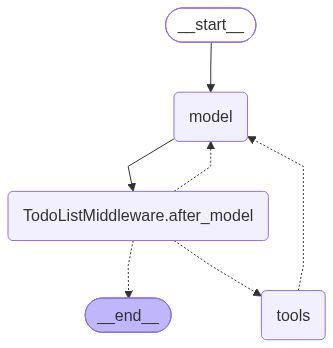

In [53]:
agent

#### Run Agent

In [54]:
response = agent.invoke({'messages': [HumanMessage('how weather effect the jhansi logistics?')]})
response

{'messages': [HumanMessage(content='how weather effect the jhansi logistics?', additional_kwargs={}, response_metadata={}, id='7540a926-bec7-4750-b714-ead647f1e977'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'route_researcher', 'arguments': '{"query": "Jhansi weather logistics impact transport highway disruptions monsoon fog heatwave"}'}, '__gemini_function_call_thought_signatures__': {'call_619117': 'EmAKXgFpFH0T4PLNmP6cjiBhBeN7VHiX0yUv+Ovm8NDINAvrijGl8+7qfuhhJYLqW+KKRcmsS6yj07X1LvRmC0+XGuJQSB2d8XdVvyqMQRpfor693eV2k9lS/x+Zv18ICwY='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a10f7e-a106-7e20-aea8-3f94adba65da-0', tool_calls=[{'name': 'route_researcher', 'args': {'query': 'Jhansi weather logistics impact transport highway disruptions monsoon fog heatwave'}, 'id': 'call_619117', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_t

In [55]:
from IPython.display import display, Markdown

display(Markdown(response['messages'][-1].text))


Here is the current logistics and weather impact analysis for the **Jhansi** transit and logistics hub:

### 🌤️ Current Weather Conditions
* **Condition:** Clear sky
* **Temperature:** 29.9°C (Feels like 32.9°C)
* **Precipitation:** 0.0 mm (Dry conditions, zero rainfall)
* **Wind Speed:** 7.7 km/h 
* **Visibility:** Excellent (~10.86 km)
* **Weather Severity:** **None / Optimal**

---

### 🚚 Operational Logistics Impact on the Jhansi Corridor

1. **Precipitation & Waterlogging (Monsoon Impact):**
   * **Current Status:** Favorable. With 0.0 mm rainfall and dry road surfaces, there are **no waterlogging or hydroplaning risks** along key national highways intersecting Jhansi (such as NH-27, NH-39, and NH-44). Heavy commercial vehicles (HCVs) can operate at standard turnaround times.
   * **Risk Factor:** During active monsoon seasons, heavy downpours frequently cause localized flooding around low-lying underpasses and arterial entry points into Jhansi, leading to multi-hour freight delays.

2. **Visibility & Fog Hazards:**
   * **Current Status:** Favorable. Visibility is clear at over 10.8 km. 
   * **Risk Factor:** During peak winter months (December–January), dense fog blankets the Bundelkhand region, drastically reducing visibility below 50 meters. This forces transport operators to observe reduced speed limits, halt night-time dispatching, and increases the risk of rear-end collisions on unlit highway stretches.

3. **Temperature & Thermal Stress (Heatwave Impact):**
   * **Current Status:** Moderate (~30°C). Normal operating conditions apply.
   * **Risk Factor:** During extreme summer months (May–June), temperatures in Jhansi routinely exceed 45°C. This creates severe operational challenges:
     * **Tire Blowouts:** High asphalt temperatures increase tire pressure and friction, elevating blowout risks for fully loaded HCVs.
     * **Refrigerated Transport (Reefer):** Perishable cargo requires higher cooling loads, increasing fuel consumption and placing strain on auxiliary diesel generator units.
     * **Driver Fatigue:** Extreme heat mandates strict driver rotation and hydration breaks to prevent heat exhaustion and microsleep incidents.

4. **Highway & Traffic Disruptions:**
   * Real-time highway monitoring indicates **no active roadblocks, severe accidents, or climate-related structural closures** currently impacting the Jhansi logistics node.

### 💡 Strategic Recommendations for Fleet Managers
* **Current Operations:** Dispatchers can maintain standard scheduling and dispatch logs without weather-related buffer times.
* **Proactive Monitoring:** Continue tracking meteorological advisories if dispatching perishable or time-sensitive freight through the Bundelkhand corridor during seasonal shifts (extreme summer heat or winter dense fog).

----

## *<span style="color: #3182ce;">Route Analyst Agent</span>
- `route_analyst`: Evaluates route trade-offs, computes multi-objective risk/cost scores (fuel, tolls, road risk, weather risk, objective_j_score), and ranks candidate routes based on cargo and vehicle constraints.

In [12]:
ROUTE_ANALYST_SYSTEM_PROMPT = """You are the Route Analyst Agent for SupplyNet. Your sole role is to evaluate commercial freight route trade-offs and perform precise, multi-objective monetary cost and risk calculations.

### YOUR INPUT DATA:
You will receive raw route and corridor data from the supervisor agent, including:
- Road distance (in km) and estimated travel duration (in minutes)
- Cargo weight (in kg)
- Vehicle axle count
- Priority level ("HIGH" or "STANDARD")
- Traffic congestion status and weather conditions along the corridor

### COMPUTATION & EVALUATION PROTOCOL:
When evaluating a candidate route, perform the following exact calculations:

1. CARGO & FUEL COST COMPUTATION:
   - Calculate cargo weight in tonnes: cargo_tonnes = cargo_weight_kg / 1000.0
   - Compute fuel efficiency (km/L): fuel_efficiency = max(2.2, 3.5 - (cargo_tonnes * 0.04))
   - Compute total diesel volume needed: liters = road_distance_km / fuel_efficiency
   - Compute total fuel cost (at base rate of 90 INR/L): fuel_cost = round(liters * 90.0, 2)

2. TOLL CHARGE COMPUTATION:
   - Compute vehicle axle factor: axle_factor = max(1.0, axle_count / 2.0)
   - Compute total estimated tolls: toll_cost = round(road_distance_km * 3.8 * (0.8 + (0.2 * axle_factor)), 2)

3. DYNAMIC RISK INDEXING (Scores range strictly from 0.00 to 1.00):
   - Traffic Congestion Penalty: +0.10 if traffic status is "HEAVY", otherwise 0.00
   - Road Risk Score: road_risk_score = round(min(0.85, 0.25 + (cargo_tonnes / 100.0) + traffic_penalty), 2)
   
   - Weather Severity Penalty: +0.25 for RAIN/FOG; +0.50 for STORM/FLOOD; 0.00 for CLEAR
   - Weather Risk Score: weather_risk_score = round(min(1.00, 0.15 + weather_penalty), 2)

4. COMPOSITE OBJECTIVE J-SCORE:
   - Priority Multiplier: priority_weight = 1.2 if priority == "HIGH" else 1.0
   - Total Monetary Cost: total_cost = fuel_cost + toll_cost
   - Composite J-Score Formula: 
     objective_j_score = round(((total_cost * 0.0001) * priority_weight) + (road_risk_score * 2.0) + (weather_risk_score * 1.5), 2)

### OUTPUT EXPECTATIONS:
Return a clean, structured result containing only your evaluated numbers:
- `fuel_cost` (float)
- `toll_cost` (float)
- `road_risk_score` (float)
- `weather_risk_score` (float)
- `objective_j_score` (float)
- `analyst_summary` (short string detailing trade-offs and rationale)
"""

In [13]:
route_analyst_agent = create_agent(
    model=model,
    tools=[],
    system_prompt=ROUTE_ANALYST_SYSTEM_PROMPT,
    
)

In [14]:
@tool
def run_route_analyst(task_instruction: str) -> str:
    """
    Call this tool to analyze route research data and compute costs, risks, and scores.
    Pass all necessary research findings and optimization criteria in 'task_instruction'.
    """
    response = route_analyst_agent.invoke({
        "messages": [("user", task_instruction)]
    })
    
    return response["messages"][-1].content

## *<span style="color: #34ce31;">Route Optimization Agent Supervisor</span>
<img src="img1.png" width="70%">


### Formated Output

In [15]:
from pydantic import BaseModel, Field
from typing import List, Literal, Optional

# 1. Define your schemas
class GeoJSONLineString(BaseModel):
    type: Literal["LineString"] = "LineString"
    coordinates: List[List[float]] = Field(..., description="List of [lon, lat] pairs")

class SelectedRoute(BaseModel):
    distance_km: float = Field(..., description="Total road distance in kilometers")
    duration_minutes: float = Field(..., description="Total estimated duration in minutes")
    fuel_cost: float = Field(..., description="Estimated total fuel cost in INR")
    toll_cost: float = Field(..., description="Estimated total toll charges in INR")
    road_risk_score: float = Field(..., description="Calculated road risk index (0.0 to 1.0)")
    weather_risk_score: float = Field(..., description="Calculated weather risk index (0.0 to 1.0)")
    objective_j_score: float = Field(..., description="Multi-objective optimization cost score")
    geometry: GeoJSONLineString

class Checkpoint(BaseModel):
    name: str = Field(..., description="Checkpoint / Transit Hub name")
    lat: float
    lon: float
    estimated_arrival_minutes: Optional[float] = None
    risk_level: Optional[str] = None

class OptimizationResponse(BaseModel):
    shipment_id: str = Field(..., description="Matches request shipment_id")
    status: Literal["SUCCESS", "FAILED"] = "SUCCESS"
    selected_route: SelectedRoute
    checkpoints: List[Checkpoint]

In [16]:
system_prompt = """You are the Lead Route Optimization Supervisor Agent for SupplyNet. Your sole objective is to orchestrate multi-objective route planning for commercial freight shipments and output a strictly structured response conforming to the required schema.

### YOUR CAPABILITIES & TOOLS
You have access to two specialized tools:
1. `route_researcher`: Fetches real-world ground data via MCP servers, including OSRM distances, waypoints/geometry, current weather risks, traffic disruptions, and toll charges.
2. `route_analyst`: Evaluates route trade-offs, computes multi-objective risk/cost scores (fuel, tolls, road risk, weather risk, objective_j_score), and ranks candidate routes based on cargo and vehicle constraints.


### INPUT PARSING PROTOCOL
The user input may arrive as a raw JSON payload (from the OptimizationRequest API) or as a natural language query. 
Extract the following parameter fields from the request:
- `shipment_id`: Extract string identifier (default to "SHIP-GENERIC-001" if missing).
- `origin`: Extract lat/lon floats. If city names are given (e.g., "Delhi"), resolve to [lat, lon].
- `destination`: Extract lat/lon floats. If city names are given (e.g., "Vellore"), resolve to [lat, lon].
- `cargo_weight`: Extract weight in kg from `cargo.weight_kg` or text (default to 10000.0 if missing).
- `axle_count`: Extract from `constraints.axle_count` or text (default to 4 if missing).
- `priority`: Extract "HIGH" or "STANDARD" from `priority` field (default to "STANDARD" if missing).



---

### WORKFLOW PROTOCOL
Follow this strict 3-step execution loop for every request:

1. **GATHER GROUND FACTS (`route_researcher`)**
   - Extract the origin coordinates, destination coordinates, axle count, priority level, and cargo weight from the request.
   - Call `route_researcher` with a clear, specific query asking for route paths, distance, key intermediate waypoints/city coordinates (like major highway junctions along the corridor), current weather alerts, and highway toll fees.

2. **ANALYZE & SCORE (`route_analyst`)**
   - Take the raw facts returned by `route_researcher` and pass them into `route_analyst`.
   - Ensure the analyst calculates:
     - `fuel_cost` (based on distance, cargo weight, and fuel efficiency)
     - `toll_cost` (based on distance and vehicle axle count)
     - `road_risk_score` (between 0.00 and 1.00)
     - `weather_risk_score` (between 0.00 and 1.00)
     - `objective_j_score` (the composite multi-objective score considering cost and risk)

3. **CONSTRUCT FINAL STRUCTURED RESPONSE**
   - Synthesize all findings and populate the output schema (`OptimizationResponse`) according to the formatting rules below.

---

### OUTPUT FORMATTING RULES
You must populate ALL required fields in the schema accurately:

- `shipment_id`: Must exactly match the input `shipment_id`.
- `status`: Set to "SUCCESS" if a valid route was found and analyzed, otherwise "FAILED".
- `selected_route`:
  - `distance_km`: Total road distance (float).
  - `duration_minutes`: Estimated total travel time in minutes (float).
  - `fuel_cost`: Fuel cost in INR (float).
  - `toll_cost`: Total toll expenses in INR (float).
  - `road_risk_score`: Road risk index from 0.00 to 1.00 (float).
  - `weather_risk_score`: Weather risk index from 0.00 to 1.00 (float).
  - `objective_j_score`: Composite objective score (float).
  - `geometry`:
    - `type`: Must be "LineString".
    - `coordinates`: A list of `[lon, lat]` pairs representing the polyline path from origin to destination (e.g., `[[origin_lon, origin_lat], [waypoint1_lon, waypoint1_lat], ..., [dest_lon, dest_lat]]`). **CRITICAL: Coordinates must be in [Longitude, Latitude] order.**
- `checkpoints`: A list of major intermediate transit hubs/cities along the selected route with their coordinates (`lat`, `lon`), estimated arrival time in minutes, and risk level ("LOW", "MEDIUM", "HIGH").

Do not guess missing data if tools fail; make reasonable logistics assumptions for intermediate coordinates if necessary, but keep all numeric metrics realistic and consistent with tool findings."""

In [17]:
from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

# Ensure directory exists
os.makedirs("data", exist_ok=True)
#db_path = project_root / "data" / "financial_agent.db"

# Ensure the "data" directory exists relative to project_root
#db_path.parent.mkdir(parents=True, exist_ok=True)
conn = sqlite3.connect("data/routing_optimization_agent.db", check_same_thread=False)
checkpointer = SqliteSaver(conn=conn)

In [18]:
# 2. Create the agent with response_format
supervisor_agent = create_agent(
    model=model,
    tools=[route_researcher,run_route_analyst],
    system_prompt=system_prompt,
    response_format=OptimizationResponse,
    checkpointer = checkpointer,
    middleware=[TodoListMiddleware()]
)

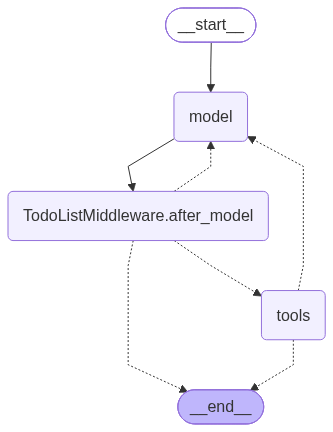

In [19]:
supervisor_agent

# Sample Inputs


In [24]:

# Delhi to Vellore (Electronics / Auto Parts Freight)
query1 = """{
  "shipment_id": "SHIP-DEL-VEL-2026-089",
  "priority": "HIGH",
  "origin": {
    "lat": 28.6139,
    "lon": 77.2090
  },
  "destination": {
    "lat": 12.9165,
    "lon": 79.1325
  },
  "cargo": {
    "weight_kg": 16500.0
  },
  "constraints": {
    "axle_count": 4
  }
}"""

In [25]:

#Mumbai to Bengaluru (Pharma / Consumer Goods Freight)
query2 = """{
  "shipment_id": "SHIP-BOM-BLR-2026-042",
  "priority": "HIGH",
  "origin": {
    "lat": 19.2812,
    "lon": 73.0482
  },
  "destination": {
    "lat": 13.0285,
    "lon": 77.5197
  },
  "cargo": {
    "weight_kg": 11200.0
  },
  "constraints": {
    "axle_count": 3
  }
}"""

In [61]:
# Jhansi to Visakhapatnam (Heavy Machinery / Industrial Equipment)
query3 = """{
  "shipment_id": "SHIP-JHS-VSKP-2026-104",
  "priority": "STANDARD",
  "origin": {
    "lat": 25.4484,
    "lon": 78.5685
  },
  "destination": {
    "lat": 17.6868,
    "lon": 83.2185
  },
  "cargo": {
    "weight_kg": 24800.0
  },
  "constraints": {
    "axle_count": 6
  }
}"""

# The calling of Route Optimization Agent

#### response with check pointer

In [21]:
config = {"configurable": {"thread_id": "memory_session2"}}
response = supervisor_agent.invoke({'messages': [query1]}, config=config)

NameError: name 'query1' is not defined

#### before normal

In [30]:
response = supervisor_agent.invoke({'messages': [HumanMessage(query1)]})


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


#### with streaming response

In [22]:
from SupplyNet_MCP.scripts.agent_utils import stream_agent_response

In [26]:
config = {"configurable": {"thread_id": "memory_session2"}}
stream_agent_response(supervisor_agent, query2, config)

Deserializing unregistered type __main__.OptimizationResponse from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'OptimizationResponse')]



  Tool Called: route_researcher
   Args: {'query': 'Find optimal route, distance, intermediate waypoints between Mumbai/Thane (19.2812, 73.0482) and Bengaluru (13.0285, 77.5197) for a 3-axle truck carrying 11200 kg cargo, checking highway tolls, weather conditions, and road disruptions along NH48 corridor.'}


  Tool Result (length: 3236 chars)



Direct use of automatic function calling (AFC) in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream. Similarly, direct use of AFC in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message.



  Tool Called: run_route_analyst
   Args: {'task_instruction': 'Analyze the route from Mumbai (19.2812, 73.0482) to Bengaluru (13.0285, 77.5197) for shipment SHIP-BOM-BLR-2026-042.\nCargo weight: 11200.0 kg, Axle count: 3, Distance: 982.5 km.\nCompute fuel cost, toll cost, road risk score, weather risk score, objective_j_score, geometry (LineString in [lon, lat]), and checkpoints list (Mumbai, Pune, Satara, Kolhapur, Belagavi, Hubballi, Tumakuru, Bengaluru).'}


  Tool Result (length: 969 chars)

{
  "shipment_id": "SHIP-BOM-BLR-2026-042",
  "status": "SUCCESS",
  "selected_route": {
    "distance_km": 982.5,
    "duration_minutes": 900.0,
    "fuel_cost": 31393.1,
    "toll_cost": 12534.88,
    "road_risk_score": 0.36,
    "weather_risk_score": 0.4,
    "objective_j_score": 1.93,
    "geometry": {
      "type": "LineString",
      "coordinates": [
        [73.0482, 19.2812],
        [73.8567, 18.5204],
        [73.9903, 17.6805],
        [74.2433, 16.705],
        [74.5089, 15.8497],

#### Output

In [27]:
from IPython.display import display, Markdown
display(Markdown(response['messages'][-1].text))


TypeError: string indices must be integers, not 'str'

### Well Formatter Output

In [49]:
import json

# Example raw output returned from your supervisor agent or subprocess
raw_response = response['messages'][-1].text

try:
    # 1. Parse string into a Python dictionary
    data = json.loads(raw_response)

    # 2. Pretty-print formatted JSON with 2-space indentation
    formatted_json = json.dumps(data, indent=2, ensure_ascii=False)
    
    print(formatted_json)

except json.JSONDecodeError as e:
    print(f"Failed to parse output as valid JSON:\n{e}")
    print(f"Raw Output:\n{raw_response}")

{
  "shipment_id": "SHIP-DEL-VEL-2026-089",
  "status": "SUCCESS",
  "selected_route": {
    "distance_km": 2160.9,
    "duration_minutes": 1956.0,
    "fuel_cost": 59132.86,
    "toll_cost": 29810.02,
    "road_risk_score": 0.42,
    "weather_risk_score": 0.15,
    "objective_j_score": 1.93,
    "geometry": {
      "type": "LineString",
      "coordinates": [
        [
          77.209,
          28.6139
        ],
        [
          78.0081,
          27.1767
        ],
        [
          78.1828,
          26.2183
        ],
        [
          78.5685,
          25.4484
        ],
        [
          79.0882,
          21.1458
        ],
        [
          78.4867,
          17.385
        ],
        [
          77.5946,
          12.9716
        ],
        [
          78.2144,
          12.5266
        ],
        [
          79.1325,
          12.9165
        ]
      ]
    }
  },
  "checkpoints": [
    {
      "name": "New Delhi",
      "lat": 28.6139,
      "lon": 77.209,
    